<a href="https://colab.research.google.com/github/brunafrnds/Brnfdes/blob/main/NASA_airfoil_self_noise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Pontifícia Universidade Católica do Paraná**
### Disciplina: Técnicas de Machine Learning
### Aluna: Bruna Fernandes



---


###**Dataset**: Airfoil Self-Noise
###**Fonte original**: https://archive.ics.uci.edu/dataset/291/airfoil+self+noise

###**Variáveis**
1. frequency (Hz)
2. attack-angle	(deg)
3. chord-length	(m)
4. free-stream-velocity	(m/s)
5. suction-side-displacement-thickness (m)
6. scaled-sound-pressure (dB)


---

##Bibliotecas

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.feature_selection import RFE
from sklearn.feature_selection import SelectFromModel

from sklearn.linear_model import LassoCV # Lasso com Cross-Validation
# --- Modelos ---
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

from sklearn.pipeline import Pipeline

##Base de Dados

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Colab/Técnicas de Machine Learning/NASA/nasa.csv', sep=';')
df.head()

,frequency,attack-angle,chord-length,free-stream-velocity,suction-side-displacement-thickness,scaled-sound-pressure
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461


In [3]:
traducao = {
    'frequency': 'frequencia',
    'attack-angle': 'angulo_ataque',
    'chord-length': 'comprimento_corda',
    'free-stream-velocity': 'velocidade_fluxo',
    'suction-side-displacement-thickness': 'espessura_deslocamento',
    'scaled-sound-pressure': 'pressao_sonora'
}
df.rename(columns=traducao, inplace=True)
df.head()

,frequencia,angulo_ataque,comprimento_corda,velocidade_fluxo,espessura_deslocamento,pressao_sonora
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461


## Análise Exploratória de Dados

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   frequencia              1503 non-null   int64  
 1   angulo_ataque           1503 non-null   float64
 2   comprimento_corda       1503 non-null   float64
 3   velocidade_fluxo        1503 non-null   float64
 4   espessura_deslocamento  1503 non-null   float64
 5   pressao_sonora          1503 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 70.6 KB


In [5]:
df.describe()

,frequencia,angulo_ataque,comprimento_corda,velocidade_fluxo,espessura_deslocamento,pressao_sonora
count,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000
mean,2886.380572,6.782302,0.136548,50.860745,0.011140,124.835943
std,3152.573137,5.918128,0.093541,15.572784,0.013150,6.898657
min,200.000000,0.000000,0.025400,31.700000,0.000401,103.380000
25%,800.000000,2.000000,0.050800,39.600000,0.002535,120.191000
50%,1600.000000,5.400000,0.101600,39.600000,0.004957,125.721000
75%,4000.000000,9.900000,0.228600,71.300000,0.015576,129.995500
max,20000.000000,22.200000,0.304800,71.300000,0.058411,140.987000


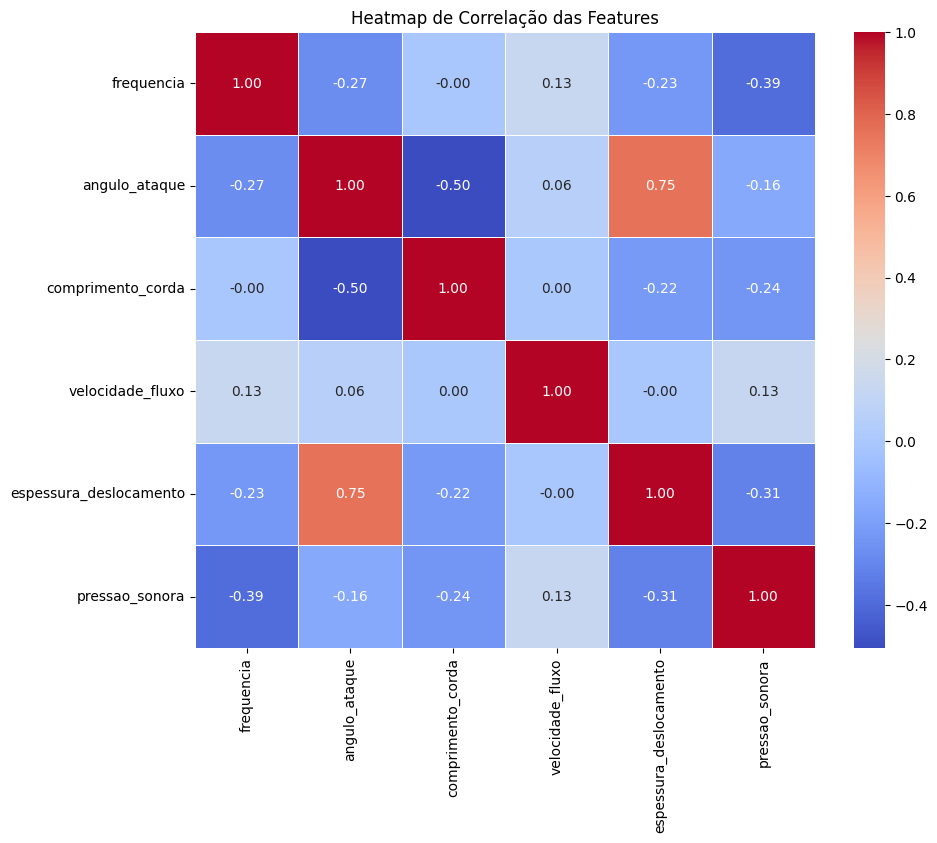

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap de Correlação das Features')
plt.show()

##Seleção de Atributos

In [7]:
X = df.drop(columns=['pressao_sonora'])
y = df['pressao_sonora']

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [9]:
#Técnica 1: Filtro (SelectKBest k=3)
k_best = SelectKBest(score_func=f_regression, k=3)
X_kbest = k_best.fit_transform(X_scaled, y)

colunas_kbest = X.columns[k_best.get_support()]
print(f"Features selecionadas: {colunas_kbest.to_list()}")

Features selecionadas: ['frequencia', 'comprimento_corda', 'espessura_deslocamento']


In [10]:
#Técnica 2: Wrapper (RFE n=3)
estimator_rfe = RandomForestRegressor(n_estimators=50, random_state=42)
rfe = RFE(estimator=estimator_rfe, n_features_to_select=3, step=1)
rfe.fit(X_scaled, y)

colunas_rfe = X.columns[rfe.support_]
print(f"Features selecionadas: {colunas_rfe.to_list()}")

Features selecionadas: ['frequencia', 'comprimento_corda', 'espessura_deslocamento']


In [11]:
#Técnica 3: Embutido (Lasso)
lasso = LassoCV(cv=5, random_state=42).fit(X_scaled, y)

selector_lasso = SelectFromModel(lasso, prefit=True, threshold=1e-5)
X_lasso = selector_lasso.transform(X_scaled)

colunas_lasso = X.columns[selector_lasso.get_support()]
print(f"Features selecionadas: {colunas_lasso.to_list()}")
print(f"Número de features: {X_lasso.shape[1]}")

Features selecionadas: ['frequencia', 'angulo_ataque', 'comprimento_corda', 'velocidade_fluxo', 'espessura_deslocamento']
Número de features: 5


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [12]:
#Técnica 5: Novas Fetures basedas nos conceitos físicos do problema
df_calculadas = df.copy()
df_calculadas['numero_strouhal'] = (df['frequencia'] * df['comprimento_corda']) / df['velocidade_fluxo']
colunas_calculadas = df_calculadas[['numero_strouhal', 'angulo_ataque', 'espessura_deslocamento', 'velocidade_fluxo' ]]
print(f"Features selecionadas: {colunas_calculadas.columns.to_list()}")

Features selecionadas: ['numero_strouhal', 'angulo_ataque', 'espessura_deslocamento', 'velocidade_fluxo']


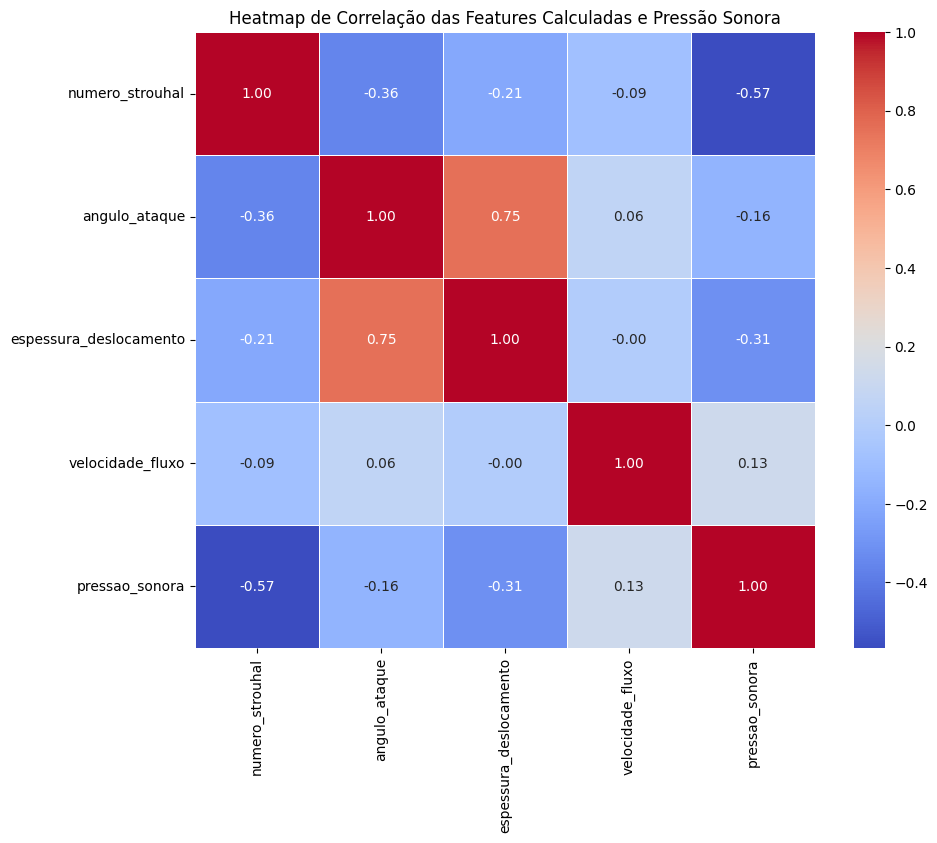

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = colunas_calculadas.copy()
heatmap_data['pressao_sonora'] = df['pressao_sonora']

correlation_matrix = heatmap_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap de Correlação das Features Calculadas e Pressão Sonora')
plt.show()

In [14]:
datasets_para_testar = []

datasets_para_testar.append(("Original", X_scaled, y))
datasets_para_testar.append(("Filtro", X_kbest, y))
datasets_para_testar.append(("Calculadas", colunas_calculadas, y))

In [15]:
#datasets_teste

##Resumo
**Dataset 1**: "Original" (5 features) Usamos as 5 features originais para ser o baseline, qualquer outra técnica deve provar ser melhor do que simplesmente usar os dados "crus".

**Dataset 2**: Filtro (KBest) (3 features): Esta é uma abordagem estatística (neste caso, f_regression), para selecionar as 'K' features que têm a maior correlação estatística com o alvo. No teste, foi selecionado a frequencia, comprimento_corda e espessura_deslocamento com a maior correlação, o mesmo resultado pode ser observado o headmad, que apresenta os valores de correlçao: frequencia (-0,39), comprimento_corda (-0,24) e espessura_deslocamento (-0,31).

**Dataset 3**: Calculado (4 features): Essa técnica foi baseada em conceitos físicos, o problema é de aerodinâmica, uma área da física que sugere que as relações entre as variáveis são mais importantes que elas mesmas. Baseado no artigo da NASA (disponível no link: https://ntrs.nasa.gov/citations/19890016302) foi calculado o Número de Strouhal ($St = \frac{f \cdot L}{V}$), uma grandeza física adimensional que combina frequencia, comprimento_corda e velocidade_fluxo. A hipótese é que esta única feature com significado físico seria mais poderosa para o modelo do que as 3 features originais separadas. Modelos lineares, por exemplo, não conseguem "aprender" sozinhos a multiplicar e dividir features, como resultado já é possível observar que essa nova feature tem a maior correlação observada (-5,57).

A técnica 2 ( Wrapper) e 3 (Lasso) foram desconsideradas pois apresentar o mesmo resultados da técnica ed filtro e o dataset original, respectivamente.


##Teste dos Modelos

In [16]:
modelos = {
        "LinearRegression": LinearRegression(),
        "SVR": SVR(),
        "RandomForest": RandomForestRegressor(random_state=42),
        "GradientBoosting": GradientBoostingRegressor(random_state=42)
    }

In [17]:
def rmse(y_true, y_pred):
    """Calcula a raiz do erro quadrático médio."""
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [18]:
resultados = []
for nome_dataset, X, y in datasets_para_testar:

    # Separar em Treino e Teste (75/25)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

    for nome_modelo, modelo in modelos.items():

        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', modelo)
        ])

        # Treinar
        pipeline.fit(X_train, y_train)

        # Prever
        y_pred = pipeline.predict(X_test)

        #Métricas
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        val_rmse = rmse(y_test, y_pred)

        # Armazenar resultados
        resultados.append({
            "Dataset": nome_dataset,
            "Modelo": nome_modelo,
            "R2": r2,
            "MAE (dB)": mae,
            "RMSE (dB)": val_rmse,
            "Features": X.shape[1]
        })

        print(f"  [+] Teste Concluído: Dataset='{nome_dataset}', Modelo='{nome_modelo}'")

  [+] Teste Concluído: Dataset='Original', Modelo='LinearRegression'
  [+] Teste Concluído: Dataset='Original', Modelo='SVR'
  [+] Teste Concluído: Dataset='Original', Modelo='RandomForest'
  [+] Teste Concluído: Dataset='Original', Modelo='GradientBoosting'
  [+] Teste Concluído: Dataset='Filtro', Modelo='LinearRegression'
  [+] Teste Concluído: Dataset='Filtro', Modelo='SVR'
  [+] Teste Concluído: Dataset='Filtro', Modelo='RandomForest'
  [+] Teste Concluído: Dataset='Filtro', Modelo='GradientBoosting'
  [+] Teste Concluído: Dataset='Calculadas', Modelo='LinearRegression'
  [+] Teste Concluído: Dataset='Calculadas', Modelo='SVR'
  [+] Teste Concluído: Dataset='Calculadas', Modelo='RandomForest'
  [+] Teste Concluído: Dataset='Calculadas', Modelo='GradientBoosting'


In [19]:
print("\n--- Resultados da Análise Preditiva Comparativa ---")
df_resultados = pd.DataFrame(resultados)
df_resultados_ordenado = df_resultados.sort_values(by="RMSE (dB)", ascending=True)
df_resultados_ordenado


--- Resultados da Análise Preditiva Comparativa ---


,Dataset,Modelo,R2,MAE (dB),RMSE (dB),Features
10,Calculadas,RandomForest,0.939342,1.221622,1.700741,4
2,Original,RandomForest,0.932664,1.313154,1.791906,5
6,Filtro,RandomForest,0.906716,1.496537,2.109097,3
11,Calculadas,GradientBoosting,0.880996,1.824288,2.382174,4
7,Filtro,GradientBoosting,0.831462,2.136515,2.834926,3
3,Original,GradientBoosting,0.830815,2.155551,2.840356,5
1,Original,SVR,0.683693,2.904751,3.883708,5
5,Filtro,SVR,0.655444,3.039676,4.053427,3
9,Calculadas,SVR,0.619906,3.193169,4.257336,4
0,Original,LinearRegression,0.517679,3.693619,4.795793,5


In [20]:
X_train, X_test, y_train, y_test = train_test_split(colunas_calculadas, y, test_size=0.25, random_state=42)
pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', RandomForestRegressor(random_state=42))])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
df_resultados = X_test.copy()
df_resultados['predicao_modelo'] = y_pred
df_resultados['valor_real'] = y_test

df_resultados

,numero_strouhal,angulo_ataque,espessura_deslocamento,velocidade_fluxo,predicao_modelo,valor_real
51,3.846057,0.0,0.003313,31.7,126.58130,125.045
1465,4.006309,12.3,0.041876,31.7,117.61313,118.767
184,19.242424,4.0,0.005796,39.6,119.97511,120.233
1000,3.205047,0.0,0.000439,31.7,135.89947,137.047
746,4.576577,0.0,0.000762,55.5,133.60108,134.556
...,...,...,...,...,...,...
1118,0.284993,12.7,0.012181,71.3,128.40815,130.348
155,60.575394,3.0,0.005295,31.7,110.74191,109.718
532,7.696970,2.7,0.002948,39.6,128.45531,128.139
1144,4.040909,12.7,0.013025,39.6,119.70854,123.177


In [21]:
df_resultados_teste = pd.DataFrame({
        'Valor_Real': y_test,
        'Valor_Previsto': y_pred
})
df_resultados_teste['Erro_de_Previsao'] = df_resultados_teste['Valor_Real'] - df_resultados_teste['Valor_Previsto']


In [22]:
df_resultados_teste

,Valor_Real,Valor_Previsto,Erro_de_Previsao
51,125.045,126.58130,-1.53630
1465,118.767,117.61313,1.15387
184,120.233,119.97511,0.25789
1000,137.047,135.89947,1.14753
746,134.556,133.60108,0.95492
...,...,...,...
1118,130.348,128.40815,1.93985
155,109.718,110.74191,-1.02391
532,128.139,128.45531,-0.31631
1144,123.177,119.70854,3.46846


##Resumo

**Modelos Lineares (LinearRegression, SVR)**: Foram usados para testar a hipótese de que o problema poderia ser resolvido com uma solução simples ou linear.

**Modelos de Ensemble/Árvore (RandomForest, GradientBoosting)**: São modelos muito mais complexos e não-lineares. Eles são excelentes em capturar interações complexas entre as features (ex: "SE o angulo_ataque é alto E a velocidade_fluxo é baixa, ENTÃO...")

##Resultados

A relação entre os parâmetros aerodinâmicos e o ruído gerado é **não-linear**. A LinearRegression, que teve o pior desempenho geral (RMSE de 5.14 dB no KBest), foi incapaz de modelar o fenômeno. Isso justifica o uso de modelos de ensemble mais complexos.

O melhor resultado de todo o experimento foi a combinação: **Dataset Calculado + Modelo RandomForest (RMSE de 1.696 dB)**.

Isso significa que a engenharia de features baseada em física (criar o numero_strouhal) foi uma estratégia superior à seleção de atributos estatística cega (SelectKBest). O KBest simplesmente removeu features (angulo_ataque, velocidade_fluxo) que ele achava irrelevantes (baseado em correlação linear), mas que na verdade eram cruciais para a física do problema.

O modelo (Calculado + RandomForest) obteve um MAE (Mean Absolute Error) de 1.24 dB. Isso significa que a previsão de ruído erra, em média, por apenas 1.24 dB.




In [23]:
df_resultados_ordenado

,Dataset,Modelo,R2,MAE (dB),RMSE (dB),Features
10,Calculadas,RandomForest,0.939342,1.221622,1.700741,4
2,Original,RandomForest,0.932664,1.313154,1.791906,5
6,Filtro,RandomForest,0.906716,1.496537,2.109097,3
11,Calculadas,GradientBoosting,0.880996,1.824288,2.382174,4
7,Filtro,GradientBoosting,0.831462,2.136515,2.834926,3
3,Original,GradientBoosting,0.830815,2.155551,2.840356,5
1,Original,SVR,0.683693,2.904751,3.883708,5
5,Filtro,SVR,0.655444,3.039676,4.053427,3
9,Calculadas,SVR,0.619906,3.193169,4.257336,4
0,Original,LinearRegression,0.517679,3.693619,4.795793,5
